In [1]:
# To open excel data, we'll first need to install an extra package dependency
!pip install openpyxl -qq

# Import the libary - you only have to do this once per file
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
filepath1 = './HydroData/2022SoilWetness.csv'
filepath2 = './HydroData/2023SoilWetness.csv'
filepath3 = './HydroData/2024SoilWetness.csv'
filepath4 = './HydroData/2025SoilWetness.csv'
filepath5 = './HydroData/2026SoilWetness.csv'

In [4]:
insitu1 =  pd.read_csv(filepath1)
insitu2 =  pd.read_csv(filepath2)
insitu3 =  pd.read_csv(filepath3)
insitu4 =  pd.read_csv(filepath4)
insitu5 =  pd.read_csv(filepath5)

In [5]:
datasets = [insitu1, insitu2, insitu3, insitu4, insitu5]
years = [2022, 2023, 2024, 2025, 2026]

new_colnames = {'sm_surface_wetness': 'Soil Moisture Surface Wetness'}

for i in range(len(datasets)):
    datasets[i] = datasets[i][['sm_surface_wetness','Date']].copy()
    datasets[i] = datasets[i].rename(columns=new_colnames)
    datasets[i]['Date'] = pd.to_datetime(datasets[i]['Date'])
    datasets[i] = datasets[i].set_index('Date')    

/tmp/ipykernel_190/206019368.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datasets[i]['Date'] = pd.to_datetime(datasets[i]['Date'])
/tmp/ipykernel_190/206019368.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datasets[i]['Date'] = pd.to_datetime(datasets[i]['Date'])
/tmp/ipykernel_190/206019368.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datasets[i]['Date'] = pd.to_datetime(datasets[i]['Date'])
/tmp/ipykernel_190/206019368.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing 

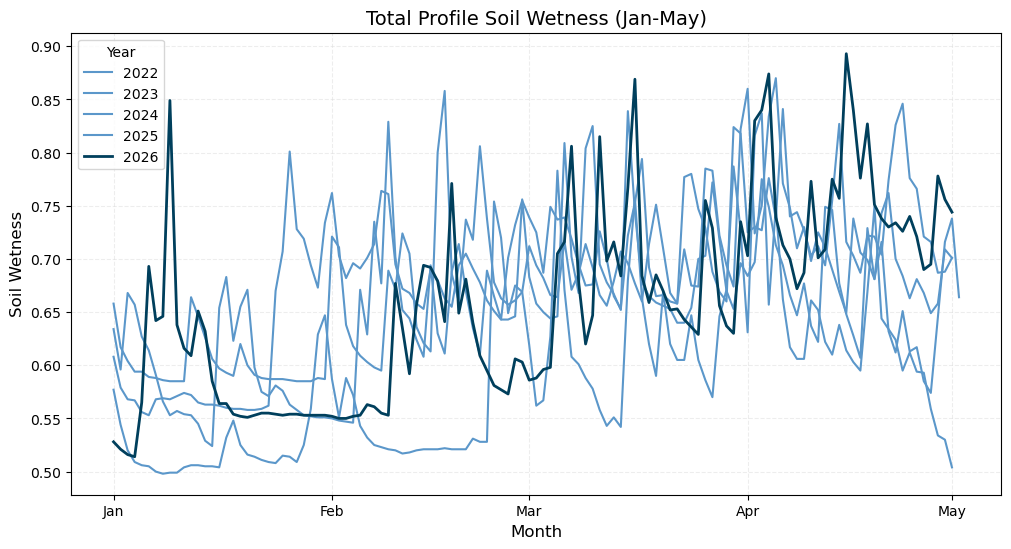

In [6]:
years = [2022, 2023, 2024, 2025,2026]
colors = {
    2022: "#5b97ca",
    2023: "#5b97ca",
    2024: "#5b97ca",
    2025: "#5b97ca",
    2026: "#003f5c",}


fig, ax = plt.subplots(figsize=(12,6))

for i in range (5):
    data = datasets[i]
    year = years[i]

    line_width = 2 if year == 2026 else 1.5


    ax.plot(
        data.index.dayofyear,
        data['Soil Moisture Surface Wetness'],
        label=str(year),
        color=colors[year],
        linewidth = line_width,
        )
        
plt.title("Total Profile Soil Wetness (Jan-May)", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Soil Wetness", fontsize=12)
plt.legend(title="Year", loc='upper left')
plt.grid(True,linestyle='--', alpha=0.5, color='gainsboro')

majorticks = [1, 32, 60, 91, 120]
plt.xticks(ticks=majorticks,  labels=['Jan', 'Feb', 'Mar', 'Apr', 'May'])

plt.show()